# You want weapons? You are connected to tools! 

"You want weapons? We're in a library! Books! The best weapons in the world! This room's the greatest arsenal we could have.", Doctor Who. What are books to Doctor Who are tools to an agent. Time to add tools but only baby ones to limit their blast radius:

```python
@tool
def greet(who: str, greeting: str = "Salve") -> str:
    return f"{greeting}, {who}!"
```

The greeting tool (`src/llm_nodes/tool_node_loop/tools.py`) is bound to the `llm_with_tools` node (`src/llm_nodes/tool_node_loop/nodes.py`), which is part of the new `tool_node_loop_node` (see below) subgraph, using [LangChain bind_tools()](https://reference.langchain.com/python/langchain/chat_models/base/_ConfigurableModel/bind_tools). Very clear and restrictive instructions are given in the prompt (`src/llm_nodes/tool_node_loop/prompts.py`), effectively degrading the LLM to an almost deterministic function:

- use `greet()` to replace every unique PII placeholder - "who" - with the return value of `greet(<pii_placeholder>)` when building the final TODO

This may sound way too trivial as a task when you think of today's frontier models. But switch the notebook to the pre-installed 3B model `ollama_chat/llama3.2:3b`, and see what happens. You will immediately understand why there's a little bells and whistles added here and there. 

... just a few new imports here from `src/llm_nodes/tool_node_loop` — the rest is unchanged. Phoenix traces slowly become valuable, so we keep them. 

In [1]:
import sys

# See README.md - only valid for devcontainer workflow!
sys.path.insert(0, "/workspace")


from src.tracing.phoenix import enable_langgraph_tracing

enable_langgraph_tracing(batch=True, verbose=False)

import os

endpoint = os.getenv("PHOENIX_COLLECTOR_ENDPOINT")
if not endpoint:
    raise RuntimeError(
        "Missing PHOENIX_COLLECTOR_ENDPOINT. "
        "Set it in container/compose/.env and restart the dev container."
    )
print(endpoint)


from src.reducer.base_reader import BaseReducerReader

from langgraph.graph import END, START, StateGraph
from langchain_core.messages import HumanMessage
import logging


from IPython.display import Image, display
from src.llm_nodes.global_state import GlobalState
from src.logging_setup import get_logger
from src.reducer.reducer_session import reducer_session
from src.llm_nodes.pii_email.nodes import get_pii_email_node
from src.llm_nodes.todo_extract.graph import build_todo_extract_subgraph, make_todo_extract_subgraph_runner
from src.llm_nodes.tool_node_loop.graph import (
    build_tool_node_loop_subgraph,
    make_tool_node_loop_subgraph_runner,
)
from src.llm_nodes.pii_email.mask import demask_pii_emails

# MODEL = "ollama_chat/llama3.2:3b"
MODEL = "groq/llama-3.3-70b-versatile"

pii_email = """
This is a confidential email.

Task ulf.wendel@ phpdoc dot de to buy a cup of coffee, ulf.wendel@phpdoc.de needs to plant a tree by tomorrow,
and cto@ourcompany.com needs to reach out to all employees 
regarding the current coffee shortage as it is demotivating our technical staff.
Due date, if not said otherwise, is today.
"""

GRAPH_RECURSION_LIMIT = 50

logger = get_logger(__name__, "assorted/session6/tool_node_basics.ipynb")
logger.setLevel(logging.DEBUG)


todo_extract_graph = build_todo_extract_subgraph(MODEL)
run_todo_extract_graph = make_todo_extract_subgraph_runner(todo_extract_graph)

tool_node_loop_graph = build_tool_node_loop_subgraph(MODEL)
run_tool_node_loop_graph = make_tool_node_loop_subgraph_runner(tool_node_loop_graph)

https://caddy:6006/v1/traces


## New subgraph: tool_node_loop

The key difference between nodes up to this point and the new `tool_node_loop_node` subgraph is a conditional edge (`src/llm_nodes/tool_node_loop/graph.py`) in the subgraph to implement the ReAct pattern:

```python
builder.add_conditional_edges(
        "llm_with_tools",
        route_after_llm_with_tools,
        {"tools": "tools", "policy_exhausted": "policy_exhausted", "finalize": "finalize"},
    )
```

`llm_with_tools` is the LLM node instructed to build the final TODO using return values from the `greet()` tool. A router named `route_after_llm_with_tools` (`src/llm_nodes/tool_node_loop/graph.py`) decides which node to execute next. The router returns a string acting as a key for the path mapping, the third parameter of [`add_conditional_edges`](https://reference.langchain.com/python/langgraph/graph/state/StateGraph/add_conditional_edges):

- "tools" -> proceed with node `tools`, which runs the tools
- "policy_exhausted" -> proceed with node `policy_exhausted`, to reduce the blast radius by raising a custom `PolicyViolationError` (`src/errors.py`)
- "finalize" -> the ReAct loop stops; `_finalize` and `_audit_placeholders` validate the reply deterministically before the subgraph ends

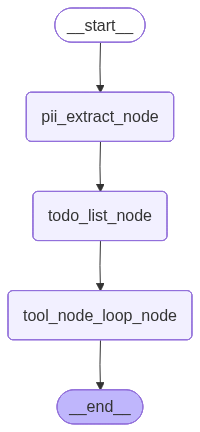

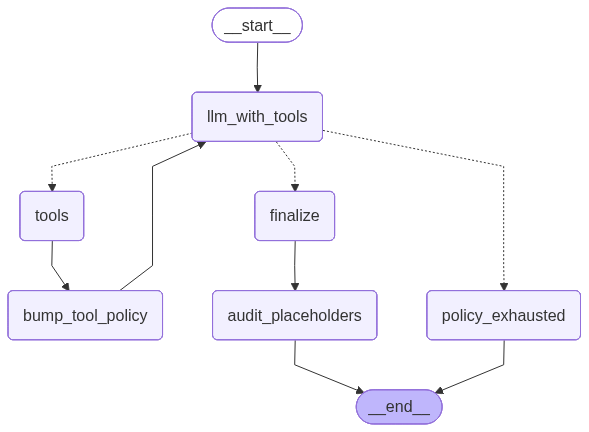

In [2]:
build_graph = StateGraph(GlobalState)

build_graph.add_node("pii_extract_node", get_pii_email_node(model=MODEL))
build_graph.add_node("todo_list_node", run_todo_extract_graph)
build_graph.add_node("tool_node_loop_node", run_tool_node_loop_graph)

build_graph.add_edge(START, "pii_extract_node")
build_graph.add_edge("pii_extract_node", "todo_list_node")
build_graph.add_edge("todo_list_node", "tool_node_loop_node")
build_graph.add_edge("tool_node_loop_node", END)

graph = build_graph.compile()

display(Image(graph.get_graph().draw_mermaid_png()))
display(Image(tool_node_loop_graph.get_graph().draw_mermaid_png()))


## The conditional edge router

The very first step in the custom router is to validate a policy:

- the LLM must not exceed the budget for `tools`-node visits (`tool_round` vs. `max_tool_rounds`, derived from unique `who` values plus headroom); with `parallel_tool_calls=False` that is typically one `greet()` per visit
- the loop must abort when a certain tool execution error threshold is exceeded (`tool_errors` vs. `max_tool_errors`)

The limits are kept in the subgraph state. They are calculated by the Pydantic model validator `_derive_tool_policy_limits()` (`src/llm_nodes/tool_node_loop/models.py`) when the subgraph state is built as part of the `ainvoke(...)` (respectively `invoke(...)`) call (`src/llm_nodes/tool_node_loop/graph.py`).

`policy_exhausted` applies only when the last `AIMessage` still has pending `tool_calls` **and** a limit is exceeded. Otherwise the router may still route to `finalize`. The `policy_exhausted` node:

```python
builder.add_node("policy_exhausted", _policy_exhausted)
...
async def _policy_exhausted(state: ToolNodeLoopState) -> dict:
    """Guard node: policy exhausted before a valid final deliverable was produced."""
    ...
    raise PolicyViolationError(
        ...
    )
```

When it runs, it raises an exception to reduce the blast radius: hey, kid, you reached your TV limit, TV off.
 
If the LLM still has a budget left for tool calls, the router decides on the `tools` path. `tools` is a node of the subgraph:

```python
builder.add_node("tools", get_tool_node_loop_tool_node())
...
HANDLE_TOOL_ERRORS = True
_TOOL_NODE = ToolNode(TOOLS, handle_tool_errors=HANDLE_TOOL_ERRORS)

def get_tool_node_loop_tool_node() -> ToolNode:
    return _TOOL_NODE
```

[`ToolNode`](https://reference.langchain.com/python/langgraph.prebuilt/tool_node/ToolNode) is a node type provided by LangGraph for handling tool execution. ToolNode executes the `tool_calls` requested in the last `AIMessage` from the state and adds `ToolMessages` to the state. Here, we tell ToolNode which `TOOLS` exist and ask it to handle errors and give error details in a `ToolMessage`. From the `tools` node it goes back to the LLM via a housekeeping hop:

```python
builder.add_edge("tools", "bump_tool_policy")
builder.add_edge("bump_tool_policy", "llm_with_tools")
```

The housekeeper `bump_tool_policy` increments trusted policy counters (`tool_round` and failed `ToolMessage`s in that round). This is the classical ReAct pattern: Reason (`llm_with_tools`), Act (`tools`), Observe (`llm_with_tools` reads the `ToolMessage` on the next turn).

Lastly, if no policy is violated and the LLM does not request more tool calls, the router decides on "finalize".

## The "finalize" guard

To further reduce the impact of a misbehaving LLM, or a prompt not working as expected, the "finalize" guard (`src/llm_nodes/tool_node_loop/graph.py`) verifies the result before the placeholder auditor in the same subgraph:

```python
builder.add_node("finalize", _finalize)
builder.add_node("audit_placeholders", _audit_placeholders)
...
builder.add_edge("finalize", "audit_placeholders")
builder.add_edge("audit_placeholders", END)
...
async def _finalize(state: ToolNodeLoopState) -> dict:
    """Extract final markdown and validate against todo_list_json (trusted, no LLM)."""
    ...
```

The finalizer verifies that every "who", every PII placeholder, is still present in the TODO. The idea is to have a deterministic soft check for the completeness of the TODO. Even if the LLM does merge the "what" under a single bullet point or leave them out entirely, or removes the "when", we still expect at least the assignees to be present in the result. 

## The messages

If you are curious about the messages: here you go. Also mind the trace on the [Phoenix UI](https://localhost:6006). 

In [3]:
def make_reader(get_thread_id):
    return BaseReducerReader(get_thread_id=get_thread_id)


with reducer_session("Chat-ABC", factory=make_reader) as session:
    state = session.state(GlobalState, [HumanMessage(content=pii_email)])
    reply = await session.ainvoke(
        graph,
        state,
        config={"recursion_limit": GRAPH_RECURSION_LIMIT},
    )
    state = GlobalState.model_validate(reply)

    print("TODO list:")
    for k, item in enumerate(state.todo_list.items):
        print(f"  {k + 1}): who={item.who}, what={item.what}, when={item.when}")

    print("\ntool_node_loop result (todo_text):")
    print(state.todo_text)

    print("\n--- tool loop messages ---")
    for i, m in enumerate(state.messages):
        if hasattr(m, "tool_calls") and m.tool_calls:
            print(f"[{i}] {type(m).__name__} tool_calls={m.tool_calls}")
        elif hasattr(m, "content") and isinstance(m.content, str) and m.content.strip():
            print(f"[{i}] {type(m).__name__}: {m.content[:200]}...")

    print("\nDemasked (trusted, after graph):")
    print(demask_pii_emails(state.todo_text, state.pii_email))

[DEBUG] [reducer/base_reader.py:51] observing message content: 
This is a confidential email.

Task ulf.wendel@ phpdoc dot de to buy a cup of coffee, ulf.wendel@phpdoc.de needs to plant a tree by tomorrow,
and cto@ourcompany.com needs to reach out to all employees 
regarding the current coffee shortage as it is demotivating our technical staff.
Due date, if not said otherwise, is today.

[DEBUG] [reducer/base_reader.py:51] observing message content: {"occurrences": [{"span": "ulf.wendel@ phpdoc dot de", "raw": "ulf.wendel@phpdoc.de"}, {"span": "ulf.wendel@phpdoc.de", "raw": "ulf.wendel@phpdoc.de"}, {"span": "cto@ourcompany.com", "raw": "cto@ourcompany.com"}]}
[DEBUG] [reducer/base_reader.py:51] observing message content: {"items": [{"who": "E0_158e5aaf", "what": "buy a cup of coffee", "when": "today"}, {"who": "E0_158e5aaf", "what": "plant a tree", "when": "tomorrow"}, {"who": "E1_158e5aaf", "what": "reach out to all employees regarding the current coffee shortage", "when": "today"}]}


TODO list:
  1): who=E0_158e5aaf, what=buy a cup of coffee, when=today
  2): who=E0_158e5aaf, what=plant a tree, when=tomorrow
  3): who=E1_158e5aaf, what=reach out to all employees regarding the current coffee shortage, when=today

tool_node_loop result (todo_text):
# Salve, E0_158e5aaf!
- [ ] buy a cup of coffee (by today)
- [ ] plant a tree (by tomorrow)
# Salve, E1_158e5aaf!
- [ ] reach out to all employees regarding the current coffee shortage (by today)

--- tool loop messages ---
[0] HumanMessage: 
This is a confidential email.

Task ulf.wendel@ phpdoc dot de to buy a cup of coffee, ulf.wendel@phpdoc.de needs to plant a tree by tomorrow,
and cto@ourcompany.com needs to reach out to all employee...
[1] AIMessage: {"occurrences": [{"span": "ulf.wendel@ phpdoc dot de", "raw": "ulf.wendel@phpdoc.de"}, {"span": "ulf.wendel@phpdoc.de", "raw": "ulf.wendel@phpdoc.de"}, {"span": "cto@ourcompany.com", "raw": "cto@ourco...
[2] AIMessage: {"items": [{"who": "E0_158e5aaf", "what": "buy a cup

## Try the 3B model!

If all these guards and layers do not sound right to you:

- try the 3B model
- mind this is a Lab not an attempt to create the best performing agent

Regarding the lab: parallel tool **requests** from the LLM have been disabled (`src/llm_nodes/tool_node_loop/nodes.py`):

```python
self._llm = provider().bind_tools(TOOLS, parallel_tool_calls=False)
```

Parallel execution means that the LLM can request multiple `tool_calls` at once. That would reduce LLM round-trips and runtime. We disabled it for the lab: the ReAct loop stays easier to read in Phoenix, policy rounds stay one step at a time, and small models behave more predictably. Trade-off: more LLM calls and higher token cost. A weak model might still call tools one by one anyway. 